In [1]:
from gradio_client import Client   # for api use

import ast                         # for text to list conversion (make data useful)
import pandas as pd                # for easy data use; you can use polars or whatever you like

# Accessing the API

Accessing the API is simple. You pass your key to the client, and then you will see a message the API has loaded.

In [4]:
token = '../api_creds/vi_key_1.csv'

# load my key
df = pd.read_csv(token) # easy and lazy lol; using pandas anyway ;p
api_key = df['key'][0]  # easy and lazy lol; using pandas anyway ;p

# connect to api
client = Client("verdantintel/verdanteye", token=api_key)

# if the API does a "ReadTimeout", it means the API was asleep and if you call it a minute later it will be back online
# I will put it behind an always-on API when more people are paying for it. Currently, I am the only one who seems to be
# using it, so I do not mind. :)

Loaded as API: https://verdantintel-verdanteye.hf.space


# Helper Function

In [5]:
def ask_api(client, question):

    answer = client.predict(question=question, api_name="/predict")
    
    answer = ast.literal_eval(answer)

    return answer

# Searching for Data

In [6]:
question = 'what has been seen in the last 24 hours?'

answer = ask_api(client, question)
len(answer)

5852

In [7]:
answer[0]

{'claim': 'Rhododendron is performing at Wonder Ballroom',
 'url': 'https://www.bandsintown.com/e/1039236389-rhododendron-at-wonder-ballroom',
 'domain': 'bandsintown.com/c/hillsboro-or',
 'url_domain': 'bandsintown.com',
 'date_added': '2026-06-04 19:18:15'}

In [8]:
df = pd.DataFrame(answer)
df['date_added'] = pd.to_datetime(df['date_added'], utc=True)
df['date_added'] = df['date_added'].dt.tz_convert('America/Los_Angeles') # put into my timezone
df.sort_values('date_added', ascending=False, inplace=True)


drop_terms = [
    'news article', 'news topic', 'status update', 'event', 'ticket', 'not identified', 
    'not enough information', 'news update', 'no specific claim', 'no claim', 'unspecified news',
    'article related to', 'claim related to', 'claim not specified', 'recent news post', 'a specific report',
    'lacks specific claim', 'unclear claim', 'unspecified incident', 'no claims available',
    'news story', 'news report', 'news post', 'news item', 'current news', 'unknown claim', 'uncertain claim',
    'video clip is available', 'no clear claim', 'claim not discernible', 'not specified', 'unspecified', 
    'claim is unclear', 'news related', 'specific news', 'unspecified content', 'report related to a',
    'Claim not explicit'
]

pattern = '|'.join(drop_terms)

df = df[~df['claim'].str.contains(pattern, case=False, na=False)]


df.head()

,claim,url,domain,url_domain,date_added
0,Rhododendron is performing at Wonder Ballroom,https://www.bandsintown.com/e/1039236389-rhodo...,bandsintown.com/c/hillsboro-or,bandsintown.com,2026-06-04 12:18:15-07:00
7,What the Dance is performing at Holocene,https://www.bandsintown.com/e/108483871-what-t...,bandsintown.com/c/hillsboro-or,bandsintown.com,2026-06-04 12:18:15-07:00
12,Trans Panic is performing at Black Water Bar,https://www.bandsintown.com/e/108487493-trans-...,bandsintown.com/c/hillsboro-or,bandsintown.com,2026-06-04 12:18:15-07:00
11,Crys Matthews is performing at Artichoke Music,https://www.bandsintown.com/e/108486638-crys-m...,bandsintown.com/c/hillsboro-or,bandsintown.com,2026-06-04 12:18:15-07:00
10,Joshua Josue is performing at Turn! Turn! Turn!,https://www.bandsintown.com/e/108485438-joshua...,bandsintown.com/c/hillsboro-or,bandsintown.com,2026-06-04 12:18:15-07:00


In [9]:
df.tail() # 24 hours

,claim,url,domain,url_domain,date_added
5838,Neighborhood news for Aptos,https://lookout.co/newsletter/aptos-neighborho...,lookout.co,lookout.co,2026-06-03 12:21:00-07:00
5848,DOJ is investigating former Congressman George...,https://justthenews.com/nation/crime/doj-inves...,justthenews.com,justthenews.com,2026-06-03 12:20:20-07:00
5849,Parasitic flesh-eating flies are moving close ...,https://justthenews.com/nation/states/parasiti...,justthenews.com,justthenews.com,2026-06-03 12:20:20-07:00
5850,FBI agents fatally shot a man who was holding ...,https://justthenews.com/nation/crime/fbi-agent...,justthenews.com,justthenews.com,2026-06-03 12:20:20-07:00
5851,Groups are entering and emerging from NYC sewe...,https://justthenews.com/nation/crime/groups-en...,justthenews.com,justthenews.com,2026-06-03 12:20:20-07:00


In [10]:
df.shape

(4310, 5)

# Clustering

Clustering is useful for seeing the kinds of things that are happening. If you want to do trend analysis, start with clustering or filtering. You will want to have clustering in your skillset/toolset. Here is my graph+nlp approach, my own approach.

Tweak the similarity threshold to get what you want. 1 is exact match. 0 is no match. 0.5-0.8 is typically pretty sweet, but it depends on what you are doing. Sometimes lower is useful. Sometimes very high is useful. Be thoughtful about what you are trying to do and it will make sense. Ask me if you would like to learn more.

In [11]:
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [12]:
def cluster_text(texts, similarity_threshold=0.5):

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        lowercase=True,
        sublinear_tf=True
    )

    tfidf_matrix = vectorizer.fit_transform(texts)

    similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)
    adj_matrix = (similarity_matrix > similarity_threshold).astype(int)

    G = nx.from_numpy_array(adj_matrix)
    partition = community_louvain.best_partition(G, resolution=0.5, random_state=1337) 

    return list(partition.values())

In [13]:
df.head()

,claim,url,domain,url_domain,date_added
0,Rhododendron is performing at Wonder Ballroom,https://www.bandsintown.com/e/1039236389-rhodo...,bandsintown.com/c/hillsboro-or,bandsintown.com,2026-06-04 12:18:15-07:00
7,What the Dance is performing at Holocene,https://www.bandsintown.com/e/108483871-what-t...,bandsintown.com/c/hillsboro-or,bandsintown.com,2026-06-04 12:18:15-07:00
12,Trans Panic is performing at Black Water Bar,https://www.bandsintown.com/e/108487493-trans-...,bandsintown.com/c/hillsboro-or,bandsintown.com,2026-06-04 12:18:15-07:00
11,Crys Matthews is performing at Artichoke Music,https://www.bandsintown.com/e/108486638-crys-m...,bandsintown.com/c/hillsboro-or,bandsintown.com,2026-06-04 12:18:15-07:00
10,Joshua Josue is performing at Turn! Turn! Turn!,https://www.bandsintown.com/e/108485438-joshua...,bandsintown.com/c/hillsboro-or,bandsintown.com,2026-06-04 12:18:15-07:00


In [14]:
df['cluster'] = cluster_text(df['claim'], similarity_threshold=0.4) # reducing to capture broader topics
df.head()

,claim,url,domain,url_domain,date_added,cluster
0,Rhododendron is performing at Wonder Ballroom,https://www.bandsintown.com/e/1039236389-rhodo...,bandsintown.com/c/hillsboro-or,bandsintown.com,2026-06-04 12:18:15-07:00,0
7,What the Dance is performing at Holocene,https://www.bandsintown.com/e/108483871-what-t...,bandsintown.com/c/hillsboro-or,bandsintown.com,2026-06-04 12:18:15-07:00,1
12,Trans Panic is performing at Black Water Bar,https://www.bandsintown.com/e/108487493-trans-...,bandsintown.com/c/hillsboro-or,bandsintown.com,2026-06-04 12:18:15-07:00,2
11,Crys Matthews is performing at Artichoke Music,https://www.bandsintown.com/e/108486638-crys-m...,bandsintown.com/c/hillsboro-or,bandsintown.com,2026-06-04 12:18:15-07:00,3
10,Joshua Josue is performing at Turn! Turn! Turn!,https://www.bandsintown.com/e/108485438-joshua...,bandsintown.com/c/hillsboro-or,bandsintown.com,2026-06-04 12:18:15-07:00,4


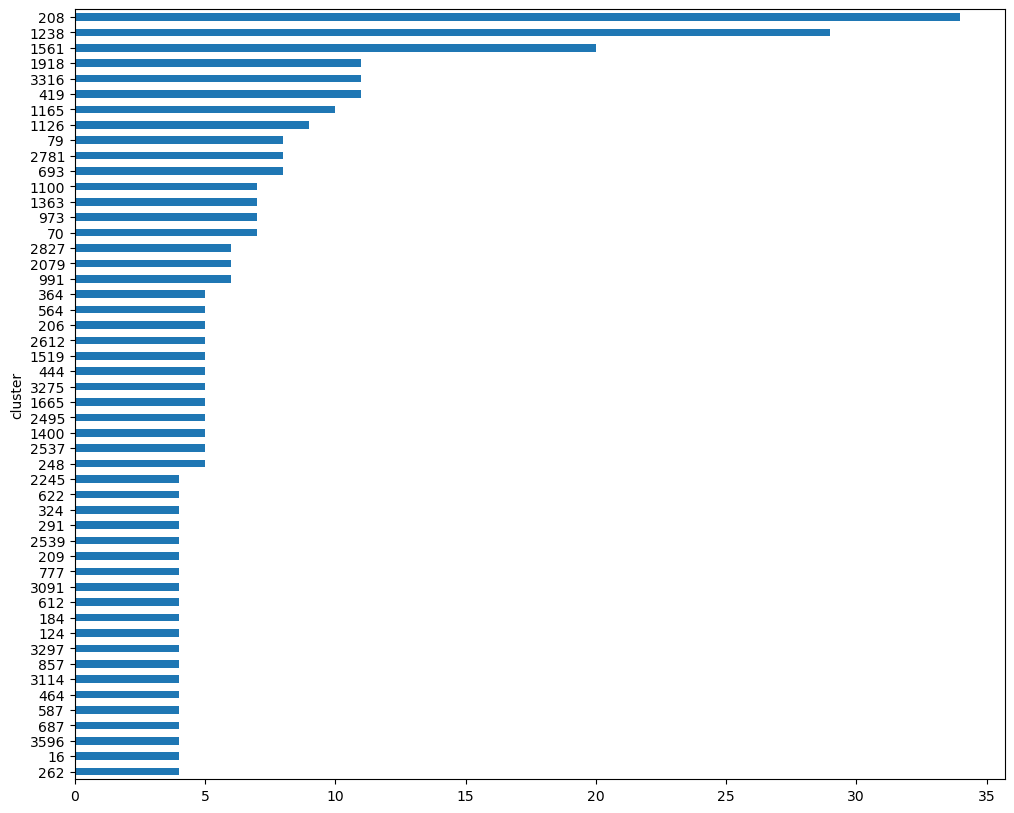

In [15]:
df['cluster'].value_counts()[0:50].plot.barh(figsize=(12,10)).invert_yaxis()

In [16]:
top_clusters = df['cluster'].value_counts().index.values
top_clusters

array([ 208, 1238, 1561, ..., 1330, 1331, 2165], dtype=int64)

In [17]:
for cluster in top_clusters[0:20]:
    
    print('cluster: {}\n'.format(cluster))
    
    cluster_data = sorted(df[df['cluster']==cluster].head(20)['claim'].values)
    for claim in cluster_data:
        print(claim)
    #print(cluster_data)
    
    print()

cluster: 208

A deadly shooting occurred at a high school graduation ceremony.
A deadly shooting occurred at a high school graduation, causing moments of terror
A high school graduation shooting resulted in one death and multiple injuries, including young children.
A shooting after a California high school graduation ceremony resulted in one teen's death.
A shooting at a California high school graduation resulted in a teen's death and a child's injury.
A shooting at a high school graduation has resulted in 18 fatalities and injuries.
A shooting at a high school graduation results in a death and multiple injuries.
A shooting following a California high school graduation ceremony has resulted in one teenager dead.
A shooting incident at Fairfield High resulted in one death and three injuries.
A shooting occurred after a graduation ceremony in the USA.
A shooting occurred at Fairfield High resulting in one death and three injuries.
One dead and three injured in a shooting during a high sc

# Good Start

That's a good start, but I want to have three different classes of cluster sizes: A, B, C. A will be biggest, then B, then C will be small clusters.

Big clusters are what everyone is talking about. The big stories.
Medium clusters are stories that are less widely talked about than big clusters.
Small clusters are stories that are talked about by few sources.

In [18]:
# simpler than binning; just gets it done. :)

def classify_cluster(count):

    if count >= 8:
        return 'A'
    elif count >= 4:
        return 'B'
    else:
        return 'C'

In [19]:
cluster_df = pd.DataFrame(df['cluster'].value_counts()).reset_index()

cluster_df['class'] = cluster_df['count'].apply(classify_cluster)

cluster_df

,cluster,count,class
0,208,34,A
1,1238,29,A
2,1561,20,A
3,1918,11,A
4,3316,11,A
...,...,...,...
3742,1328,1,C
3743,1329,1,C
3744,1330,1,C
3745,1331,1,C


In [20]:
cluster_df['count'].describe()

count    3747.000000
mean        1.150254
std         0.994701
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        34.000000
Name: count, dtype: float64

# Split into Class DFs

Now I want to split this into three DFs and loop through each one so that I can see different size clusters more easily.

In [21]:
class_a_df = cluster_df[cluster_df['class'] == 'A']
class_b_df = cluster_df[cluster_df['class'] == 'B']
class_c_df = cluster_df[cluster_df['class'] == 'C']

## Class A Clusters - Big Clusters; More Chatter

In [22]:
class_df = class_a_df
top_clusters = class_df['cluster'].values

subset_df = df[df['cluster'].isin(top_clusters)].copy()
subset_df['cluster'] = cluster_text(subset_df['claim'], similarity_threshold=0.4) # reducing to capture broader topics

top_clusters = subset_df['cluster'].value_counts().index.values
top_clusters

for cluster in top_clusters:
    
    print('cluster: {}\n'.format(cluster))
    
    cluster_data = sorted(subset_df[subset_df['cluster']==cluster].head(20)['claim'].values)
    for claim in cluster_data:
        print(claim)
    
    print()

cluster: 1

A deadly shooting occurred at a high school graduation ceremony.
A deadly shooting occurred at a high school graduation, causing moments of terror
A high school graduation shooting resulted in one death and multiple injuries, including young children.
A shooting after a California high school graduation ceremony resulted in one teen's death.
A shooting at a California high school graduation resulted in a teen's death and a child's injury.
A shooting at a high school graduation has resulted in 18 fatalities and injuries.
A shooting at a high school graduation results in a death and multiple injuries.
A shooting following a California high school graduation ceremony has resulted in one teenager dead.
A shooting incident at Fairfield High resulted in one death and three injuries.
A shooting occurred at Fairfield High resulting in one death and three injuries.
A shooting occurred at a California high school graduation ceremony, resulting in one teen killed and three others woun

## Class B Clusters - Average Sized Clusters;

In [23]:
class_df = class_b_df
top_clusters = class_df['cluster'].values

subset_df = df[df['cluster'].isin(top_clusters)].copy()
subset_df['cluster'] = cluster_text(subset_df['claim'], similarity_threshold=0.4) # reducing to capture broader topics

top_clusters = subset_df['cluster'].value_counts().index.values
top_clusters

for cluster in top_clusters:
    
    print('cluster: {}\n'.format(cluster))
    
    cluster_data = sorted(subset_df[subset_df['cluster']==cluster].head(20)['claim'].values)
    for claim in cluster_data:
        print(claim)
    
    print()

cluster: 28

New medical guidance affirms Tylenol safety during pregnancy.
New medical guidance affirms the safety of Tylenol during pregnancy after Trump raised doubts.
New medical guidance affirms the safety of Tylenol during pregnancy despite previous doubts.
New medical guidance confirms Tylenol safety during pregnancy after previous doubts
New medical guidance confirms that Tylenol is safe for use during pregnancy.
New medical guidance confirms that Tylenol is safe to use during pregnancy.
New medical guidance confirms the safety of Tylenol during pregnancy, addressing doubts raised by Trump.

cluster: 26

A collision between a train and a semi-truck leads to one death and another injury.
A train struck a semi-truck in Iowa, resulting in one death and another injury.
A train struck a semi-truck in Iowa, resulting in one death and another injury.
A train struck a semi-truck in Iowa, resulting in one death and one injury.
A train struck a semi-truck in Iowa, resulting in one death a

A staff member was shot with a crossbow at the University of Surrey campus.
A university staff member was shot with a crossbow leading to the arrest of a 21-year-old.
Crossbow attack on the University of Surrey campus leaves injuries.
Crossbow shooting incident at the University of Surrey

cluster: 20

Concern about safety for World Cup fans in Mexico
Mexico's safety for World Cup fans is in question.
The safety of Mexico for World Cup fans is uncertain.
There is a concern about the safety of Mexico for World Cup fans.

cluster: 21

Protest against budget cuts in French-language education in Brussels
Protests against cuts in French-speaking education in Brussels
Protests in French-speaking education in Brussels
Students protest against budget cuts.

cluster: 37

Police are looking for video evidence related to a triple homicide in Sandy.
Police are looking for video evidence related to a triple homicide that occurred in Sandy.
Police are looking for video evidence related to a triple h

## Class C Clusters - Small Stories; Less Chatter

In [24]:
class_df = class_c_df
top_clusters = class_df['cluster'].values

subset_df = df[df['cluster'].isin(top_clusters)].copy()
subset_df['cluster'] = cluster_text(subset_df['claim'], similarity_threshold=0.4) # reducing to capture broader topics

top_clusters = subset_df['cluster'].value_counts().index.values
top_clusters

for cluster in top_clusters:
    
    print('cluster: {}\n'.format(cluster))
    
    cluster_data = sorted(subset_df[subset_df['cluster']==cluster].head(20)['claim'].values)
    for claim in cluster_data:
        print(claim)
    
    print()

cluster: 1944

Chloe Star and Bri Carter are performing at Club 101
Eliza Niemi and More Eaze are performing at Club 101
Pacer and Maurice are performing at Club 101
Pigmilk and Deadbeat Girl are performing at Club 101

cluster: 799

A Ball State football player has died after being shot at a party.
A Ball State football player has died after being shot at a party.
Ball State football player dead after being shot at a party.

cluster: 370

SCNG has won 4 awards for housing coverage after wildfires
SCNG has won four awards for its housing coverage related to the aftermath of wildfires.
SCNG wins four awards for its housing coverage in the aftermath of wildfires.

cluster: 3127

Chemical tank emergency in Garden Grove leaking toxic chemicals could lead to a spill or explosion.
Chemical tank emergency in Garden Grove leaking toxic chemicals could lead to a spill or explosion.
Chemical tank emergency in Garden Grove leaking toxic chemicals could lead to a spill or explosion.

cluster: 1238

Maurizio Molella performing at The Glasshouse

cluster: 2609

DJ Shhh! performing at Floral Park Public Library

cluster: 2594

Teenagers have been charged regarding a knife incident at Grand Central.

cluster: 2606

Carmen Quill performing at Pacha Cafe

cluster: 2592

A convicted child murderer claims he did not commit the crime.

cluster: 2595

Five women are reported to have been raped by an individual known as 'El Brujo'.

cluster: 2605

Soni Withaneye performing at Lincoln Center Theater

cluster: 2877

Texas' biggest foam pool party experience is happening.

cluster: 2604

Charu Suri performing at Weehawken Waterfront Park and Recreation Center

cluster: 2603

Jordan Carlos performing at Comedy Cellar

cluster: 2602

Thash Mose performing at Comic Strip Live

cluster: 2596

A man accused of femicide fell asleep during a court hearing, causing outrage in Colombia.

cluster: 2879

Massive fire at a hospital's ICU in Muzaffarpur causing casualties

cluster: 2881

Family of eight pe

A vegetation fire is occurring near Brentwood.

cluster: 2763

Fire destroys dozens of houses in Johar Baru

cluster: 2771

Dunkerque's port dynamics and security challenges

cluster: 2764

Jacqueline Carrere Ponthieux exonerated after 13 years

cluster: 2765

Video shows moment drone explodes

cluster: 2766

Testimonies of women in struggle

cluster: 2767

MP reveals threats to deportees

cluster: 2768

Organized crime infiltrates elections

cluster: 2769

Dunkerque has second strongest municipal police

cluster: 2803

Tax measures in a citizens' initiative are under scrutiny for requiring only a simple majority.

cluster: 2770

Telemedicine help in birth emergencies

cluster: 2821

A pig was rescued after being on the run for months in Bridgewater.

cluster: 2823

Information about Twin Cities Pride festival

cluster: 2649

Ten individuals released after involvement in a KPK operation related to Silmy Karim's case

cluster: 2669

Report on international relations involving Finland

c

The article discusses the implications of AI and deepfakes in relation to violence in Nova Scotia.

cluster: 2044

Nelly Furtado and Tragically Hip collaborate with Boi-1da on an album for Canada's competitive World Cup.

cluster: 2045

Man molests partner's daughter in living room, mother witnesses and reports

cluster: 2046

KZN transport department condemns violent attack

cluster: 2047

Lancashire borough where 1 in 4 children admit to something

cluster: 2048

New parents missing out on free support

cluster: 2049

India detains hotel owner as fire investigation begins

cluster: 2084

Claims that Nex Playground outsells Xbox and aims to address loneliness, suggesting it could be a family game night savior.

cluster: 2086

A man has been arrested for walking through a shopping area in Melbourne.

cluster: 2147

Threat of absence due to child's illness

cluster: 2132

Police reject R19k bribe and arrest illegal mining suspect

cluster: 2121

Prophet Jacob Dangyang alleges takeover o

The article highlights a noteworthy trend or occurrence.

cluster: 2333

Ammar Farooki is performing at The Bitter End.

cluster: 2334

Ethel is performing at the Dimenna Center for Classical Music.

cluster: 2336

A man was forced at gunpoint to surrender his phone because he recorded police activity.

cluster: 2337

A hiker received four harrowing words.

cluster: 2338

A beloved Scottish zoo is forced to close.

cluster: 2339

Report on the beating death of a young husband and father of four

cluster: 2340

Shortage of ballot papers leading to protests

cluster: 2341

Insight into an 850 million dollar project

cluster: 2342

Police warning families regarding the Tiananmen crackdown

cluster: 2343

L.A. deputies are in pursuit of a driver.

cluster: 2344

A trial is underway regarding murders of unhoused individuals in Los Angeles.

cluster: 2347

The article analyzes the implications of a recent decision or action.

cluster: 2359

Politicians are implicated in the kidnapping of sch

...

A suspect shot a San Francisco police officer after being released from prison six months earlier.

cluster: 99

Local organizations are addressing senior isolation in the valley.

cluster: 100

Pritzker has an opportunity to assist children and send a message to the CTU.

cluster: 101

Molly Mae Hague's fans have detected a hint about the gender of her baby.

cluster: 102

Michael Jackson associate claims to have been asked to dispose of child abuse material

cluster: 103

San Ysidro port of entry closed and traffic is being diverted

cluster: 104

A report on a man receiving a 31-year prison sentence for a violent crime.

cluster: 105

Information about the Denver International Festival.

cluster: 106

A McDonald's worker in Yuba City was badly burned by hot oil thrown by a coworker.

cluster: 107

A groggy student dog walker was killed.

cluster: 109

Elk Grove police arrested three individuals with help from a drone after homes were damaged.

cluster: 67

Mona's support for caregiv

A man with a long history of criminal activity has been arrested by Baker City police.

cluster: 358

A man has been sentenced to jail in Grant County due to multiple driving-related convictions.

cluster: 359

An Oregonian has returned home after being exposed to hantavirus on a cruise ship.

cluster: 360

The Wallowa County Sheriff's Office is investigating a death.

cluster: 336

The biggest mistake was not being able to realize the violence in time

cluster: 335

Around 3,000 protesters have participated in a teachers' strike

cluster: 334

Protests in Albania against something related to 'Flamingo revolution'

cluster: 333

There is a public outrage in France over a suspect in a missing girl's case

cluster: 310

L.A. hospital is seeking assistance in identifying an unknown patient.

cluster: 311

Culver City bank robbery suspect is being searched for with a reward of $10,000.

cluster: 312

Dry weather is disrupting crop planting across Asia amid El Nino

cluster: 313

This Frida

Tens of thousands consume cocaine in Switzerland

cluster: 1613

A jockey has been jailed for manslaughter after an incident involving a pensioner.

cluster: 1614

An inquest is being held regarding Henry Nowak and the actions of Hampshire police concerning Vickrum Digwa.

cluster: 1615

A Cuban illegal immigrant has pleaded guilty to trafficking women into a strip club under debt bondage.

cluster: 1616

Rumors regarding the migration of homeless people from Vancouver as the World Cup nears

cluster: 1619

Rachel Reeves discusses the issues related to unemployment, redundancies, and job cuts.

cluster: 1622

October week bonus for pupils from council

cluster: 1592

Irish pub transforms in Ivory Coast

cluster: 1591

Expert explains a common health mistake

cluster: 1590

Bender's Take the West is a show at Kelly's Olympian.

cluster: 1589

Blood Orange is performing at Edgefield Concerts.

cluster: 1558

Protests against the implementation of a certain measure in Wijk Pachterslei

cl

Operatives intercepted a bus carrying missing children and made arrests.

cluster: 1114

There is an increase in premature and small babies being born among vulnerable groups.

cluster: 1116

A breakthrough drug has nearly doubled survival rates for advanced cases.

cluster: 1117

Clashes occurred between protesters and police after a demonstration.

cluster: 1118

A 37-year-old man has been indicted for 20 crimes including...

cluster: 1119

A 45-year-old male driver has been arrested for dangerous driving.

cluster: 1121

Google intends to release 64 million mosquitoes for a specific reason.

cluster: 1135

Immigration staff are using a slick modus operandi involving bank accounts and cleaning services.

cluster: 1122

Lufthansa employees were injured in a Boeing nose gear incident.

cluster: 1124

Concerns are rising in universities in Antioquia and Valle.

cluster: 1125

A government bill addresses parental consent for sex and emotional education.

cluster: 1126

Violent storms and

A bride warns couples about potential issues at weddings.

cluster: 1396

A Disney World guest was arrested for alleged wrongdoing.

cluster: 1397

An Iowa father is accused of killing six people.

cluster: 1430

Insight into political or social implications of a situation.

cluster: 1431

Update on significant changes in policy or governance.

cluster: 1432

Reporting on a new initiative or public response.

cluster: 1476

Hillsboro residents are voicing their demands regarding local growth and issues.

cluster: 1465

Farmers markets in the Bay Area are highlighted as symbols of downtown resilience

cluster: 1466

Claims of extortion involving Silmy Karim and the forced payment by foreign nationals for permits

cluster: 1467

Brexton Busch is making progress in the racing world shortly after the death of his father, Kyle Busch.

cluster: 1468

A shocking video reveals a two-tier policing system related to the death of Henry Nowak.

cluster: 1469

Lilibet, at 5 years old, mimics Meghan

In [25]:
# All paying readers who have API access can do this.
# If you do not have API access and would like to pay for it, email me at info@verdantintel.com